In [11]:
import numpy as np
from numpy import random as nprnd
import random as rnd
import pandas as pd
import string as str
from math import *

#scipy stat
import scipy.stats as ss
from scipy import stats
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import expon,zscore,zmap
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import pearsonr
#scipy signals library
from scipy import signal
#scipy calculus library
import scipy.integrate as spi



#scipy chi
from scipy.stats import chi,chi2_contingency,chi2

import math

import os
import time

import csv

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns
# Pkg import Date Time
from datetime import datetime
from datetime import timedelta
from pandas.tseries.offsets import Hour, Minute
from pandas.tseries.offsets import Day, MonthEnd
import pytz
from pandas.tseries.frequencies import to_offset
#import arviz as az
import plotly
from sympy import symbols, Eq, solve
import re #extract cofficient

###################################################
'''sklearn'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.stattools import durbin_watson
from patsy import dmatrices

from zlib import crc32
import hashlib

###################################################
'''sklearn'''
###################################################
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.datasets import fetch_openml
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score
from sklearn.datasets import make_blobs
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import learning_curve
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LogisticRegression
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error

from sklearn.datasets import load_iris

import tensorflow as tf
from tensorflow import keras

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tarfile
import urllib.request
import tensorflow as tf
from tensorflow import keras
import sys
from copy import deepcopy
# =====================================


### **Logistic Regression**

If the estimated probability > 50%, then the model predicts that the instance belongs to that class
                               (called the positive class, labeled “1”)
                               
else it predicts that it does not (i.e., it belongs to the negative class, labeled “0”).

#### Estimating Probabilities

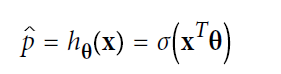

logistic—noted σ(·)—is a sigmoid function

#### Logistic function:

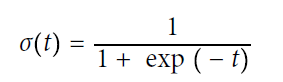

##### Logistic Regression model prediction

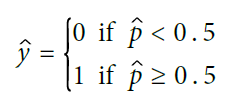

##### Training and Cost Function

Qus: How to trained ?

The objective of training is to set the parameter vector θ so that the model estimates high probabilities for positive instances (y = 1) and low probabilities for negative instances (y = 0).

Cost function of a single training instance

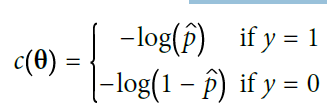

#### Logistic Regression cost function (log loss):

This cost function is convex, so Gradient Descent (or any other optimization algorithm) is guaranteed to find the global minimum.

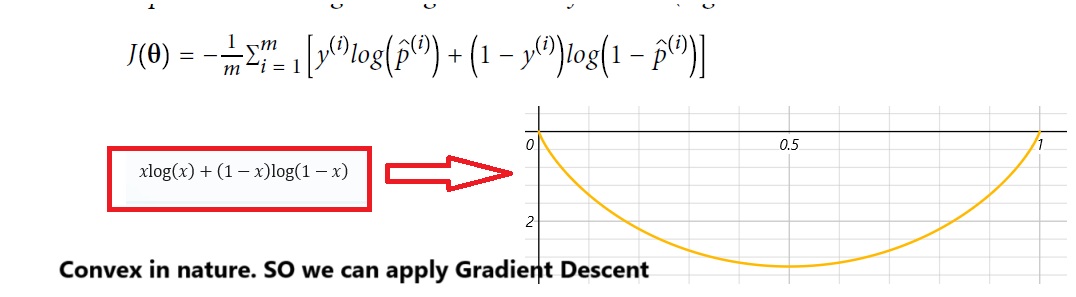

#### Logistic cost function partial derivatives

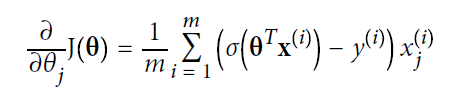





In [12]:
path = os.path.join(os.getcwd(), 'DataSet', 'Iris.csv')
df = pd.read_csv(path)
print(df['Species'].value_counts())
print(df.columns)



Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')


In [13]:
str_var_y = 'virginica'
str_var_x = 'PetalWidthCm'
df['virginica'] = df['Species'].map(lambda x: x == 'Iris-virginica')
#y,X = dmatrices("setosa ~ PetalWidthCm", data = df,return_type='dataframe')
X = df['PetalWidthCm'].to_numpy().reshape(-1,1)
y = df['virginica'].to_numpy().reshape(-1,1)



In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [15]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

c:\Users\TODO\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(random_state=42)

#### Get predicted values 


In [16]:
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)  # reshape to get a column vector
y_proba = log_reg.predict_proba(X_new)


In [17]:
# Decisions boundry
decision_boundary = X_new[y_proba[:, 1] >= 0.5][0, 0]
decision_boundary


1.6516516516516517

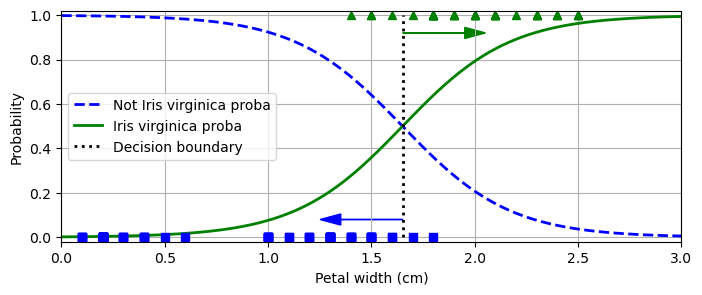

In [18]:
# Graph plot
plt.figure(figsize=(8, 3))  # extra code – not needed, just formatting
plt.plot(X_new, y_proba[:, 0], "b--", linewidth=2,
         label="Not Iris virginica proba")
plt.plot(X_new, y_proba[:, 1], "g-", linewidth=2, label="Iris virginica proba")
plt.plot([decision_boundary, decision_boundary], [0, 1], "k:", linewidth=2,
         label="Decision boundary")

# extra code – this section beautifies and saves Figure 4–23
plt.arrow(x=decision_boundary, y=0.08, dx=-0.3, dy=0,
          head_width=0.05, head_length=0.1, fc="b", ec="b")
plt.arrow(x=decision_boundary, y=0.92, dx=0.3, dy=0,
          head_width=0.05, head_length=0.1, fc="g", ec="g")
plt.plot(X_train[y_train == 0], y_train[y_train == 0], "bs")
plt.plot(X_train[y_train == 1], y_train[y_train == 1], "g^")
plt.xlabel("Petal width (cm)")
plt.ylabel("Probability")
plt.legend(loc="center left")
plt.axis([0, 3, -0.02, 1.02])
plt.grid()

In [19]:
# Predictions with test set
y_proba_test = log_reg.predict_proba(X_test)

dfx = pd.DataFrame({'Predict':np.ravel(y_proba_test[:,1]), 'Actual':np.ravel(y_test)})
#dfx


In [20]:
log_reg.predict([[1.7], [1.5]])

array([ True, False])